## S. aureus benchmark

In [ ]:
%%bash
### Create staphylococcus test set of 1,000 randin Staphylococcus genomes for testing
head -n 1000 /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/host_genome_id/agc_inputs/Staphyloccocus.txt > fasta_files.txt

awk -F/ '{print $NF"\t"$0}' fasta_files.txt > fasta_files.tsv
sed -i 's/\.fa.*\t/\t/g' fasta_files.tsv

In [ ]:
%%bash
### Create sketchlib sketch
sketchlib sketch \
    -f fasta_files.tsv \
    -o staph_s1k_k21 \
    -k 21 \
    -s 1000 \
    -v \
    --threads 16

In [ ]:
%%bash
### Create sketchlib sketch
sketchlib sketch \
    -f fasta_files.tsv \
    -o staph_s1k_k31 \
    -k 31 \
    -s 1000 \
    -v \
    --threads 16

In [ ]:
%%bash
### Calculate distance within sketch
sketchlib dist \
    staph_s1k_k31.skm \
    -o staph_s1k_k31_dist \
    -k 31 \
    --ani \
    --threads 16 \
    --verbose \
    --knn 100

In [ ]:
%%bash
### Calculate distance within sketch
sketchlib dist \
    staph_s5k_k21.skm \
    -o staph_s2k_k21_dist \
    -k 31 \
    --ani \
    --threads 16 \
    --verbose \
    --knn 100

In [ ]:
%%bash
### Run skani
skani triangle \
    -l fasta_files.txt \
    -o skani_staph_s9999 \
    --fast \
    --short-header \
    --sparse \
    -t 16 \
    -s 99.99

In [32]:
### Load data
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl

sketchlib_dist = (
    pl.read_csv('staph_s1k_k31_dist', separator='\t', has_header=False, new_columns=['genome1', 'genome2', 'ani_prop'])
        .with_columns([
            (pl.col('ani_prop') * 100).alias('ani')
        ])
)

sketchlib_s1k_dist = (
    pl.read_csv('staph_s10k_k21_dist', separator='\t', has_header=False, new_columns=['genome1', 'genome2', 'ani_prop'])
        .with_columns([
            (pl.col('ani_prop') * 100).alias('ani')
        ])
)

skani_data = (
    pl.read_csv('skani_staph_fast', separator='\t', columns=['Ref_name', 'Query_name', 'ANI', 'Align_fraction_ref', 'Align_fraction_query'])
        .rename({'ANI': 'ani', 'Ref_name': 'genome1', 'Query_name': 'genome2', 'Align_fraction_ref': 'ref_af', 'Align_fraction_query': 'q_af'})
        .with_columns([
            pl.col('genome1').str.replace(r'-scaffold.*', ''),
            pl.col('genome2').str.replace(r'-scaffold.*', ''),
            (pl.col('ani') * (pl.col('q_af')/100) * (pl.col('ref_af')/100)).alias('global_ani')
        ])
)

skani_faster_data = (
    pl.read_csv('skani_staph_s9999', separator='\t', columns=['Ref_name', 'Query_name', 'ANI', 'Align_fraction_ref', 'Align_fraction_query'])
        .rename({'ANI': 'ani', 'Ref_name': 'genome1', 'Query_name': 'genome2', 'Align_fraction_ref': 'ref_af', 'Align_fraction_query': 'q_af'})
        .with_columns([
            pl.col('genome1').str.replace(r'-scaffold.*', ''),
            pl.col('genome2').str.replace(r'-scaffold.*', ''),
            (pl.col('ani') * (pl.col('q_af')/100) * (pl.col('ref_af')/100)).alias('global_ani')
        ])
)

In [33]:
### Compare skani and sketchlib ANI values
joined = (
    sketchlib_dist
        .join(skani_data, on=['genome1', 'genome2'], how='full', coalesce=True, suffix='_skani')
        .fill_null(0)
)
print("sketchlib == 100% ANI:", joined.filter(pl.col('ani') == 100).shape[0]/2)
print("sketchlib -s 1000 == 100% ANI:", sketchlib_s1k_dist.filter(pl.col('ani') == 100).shape[0]/2)
print("skani fast == 100% ANI:", joined.filter(pl.col('global_ani') == 100).shape[0])
print("skani -s 99.99 == 100% ANI:", skani_faster_data.filter(pl.col('global_ani') == 100).shape[0])

sketchlib == 100% ANI: 215.0
sketchlib -s 1000 == 100% ANI: 15.0
skani fast == 100% ANI: 65
skani -s 99.99 == 100% ANI: 65


In [34]:
joined.filter(pl.col('ani') >= 99.9).filter(pl.col('global_ani') > 0)[['global_ani']].describe()

statistic,global_ani
str,f64
"""count""",1960.0
"""null_count""",0.0
"""mean""",97.40723
"""std""",1.775258
"""min""",85.224123
"""25%""",96.285311
"""50%""",97.556189
"""75%""",98.833191
"""max""",100.0


In [35]:
joined.filter(pl.col('ani') >= 99.99).filter(pl.col('global_ani') > 0)[['global_ani']].describe()

statistic,global_ani
str,f64
"""count""",500.0
"""null_count""",0.0
"""mean""",99.310045
"""std""",0.632524
"""min""",96.347724
"""25%""",98.912958
"""50%""",99.400857
"""75%""",99.920012
"""max""",100.0


In [39]:
joined.filter(pl.col('ani') == 100).filter(pl.col('global_ani') > 0)[['global_ani']].describe()

genome1,genome2,ani_prop,ani,ani_skani,ref_af,q_af,global_ani
str,str,f64,f64,f64,f64,f64,f64
"""RSGB23-1_GCF-010135925-V1_GENO…","""RSGB23-1_GCF-010162285-V1_GENO…",1.0,100.0,99.99,99.52,99.25,98.763723
"""RSGB23-1_GCF-010135925-V1_GENO…","""RSGB23-1_GCF-010143755-V1_GENO…",1.0,100.0,99.99,99.69,99.73,99.410895
"""RSGB23-1_GCF-003006055-V1_GENO…","""RSGB23-1_GCF-003076375-V1_GENO…",1.0,100.0,100.0,99.72,99.7,99.42084
"""RSGB23-1_GCF-010143645-V1_GENO…","""RSGB23-1_GCF-010144275-V1_GENO…",1.0,100.0,100.0,99.31,99.32,98.634692
"""RSGB23-1_GCF-010143755-V1_GENO…","""RSGB23-1_GCF-010162285-V1_GENO…",1.0,100.0,100.0,99.73,99.41,99.141593
…,…,…,…,…,…,…,…
"""RSGB23-1_GCF-022689405-V1_GENO…","""RSGB23-1_GCF-022689445-V1_GENO…",1.0,100.0,100.0,99.5,99.6,99.102
"""RSGB23-1_GCF-022689405-V1_GENO…","""RSGB23-1_GCF-022689465-V1_GENO…",1.0,100.0,100.0,99.59,99.6,99.19164
"""RSGB23-1_GCF-022689425-V1_GENO…","""RSGB23-1_GCF-022689445-V1_GENO…",1.0,100.0,100.0,99.45,99.54,98.99253


In [38]:
joined.filter(pl.col('ani') == 100).filter(pl.col('global_ani') > 0)[['ani_skani']].describe()

statistic,ani_skani
str,f64
"""count""",215.0
"""null_count""",0.0
"""mean""",99.996047
"""std""",0.005088
"""min""",99.98
"""25%""",99.99
"""50%""",100.0
"""75%""",100.0
"""max""",100.0


In [14]:
joined.filter(pl.col('genome1').str.contains('RSGB23-1_GCF-014267025-V1_GENO')).head(20)

genome1,genome2,ani_prop,ani,ani_skani,ref_af,q_af,global_ani
str,str,f64,f64,f64,f64,f64,f64
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014265885-V1_GENO…",1.0,100.0,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014266275-V1_GENO…",1.0,100.0,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014265765-V1_GENO…",1.0,100.0,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014265975-V1_GENO…",1.0,100.0,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014265415-V1_GENO…",1.0,100.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014266095-V1_GENO…",0.999984,99.998426,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014266685-V1_GENO…",0.9996803,99.96803,0.0,0.0,0.0,0.0
"""RSGB23-1_GCF-014267025-V1_GENO…","""RSGB23-1_GCF-014267045-V1_GENO…",0.9996803,99.96803,100.0,97.69,100.0,97.69


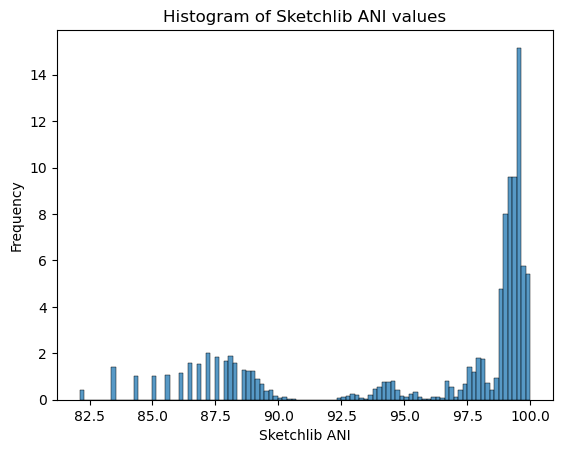

In [42]:
### Create a histogram of sketchlib ANI values to observe frequency
sns.histplot(sketchlib_dist['ani'], bins=100, stat='percent')
plt.xlabel('Sketchlib ANI')
plt.ylabel('Frequency')
plt.title('Histogram of Sketchlib ANI values')
plt.show()

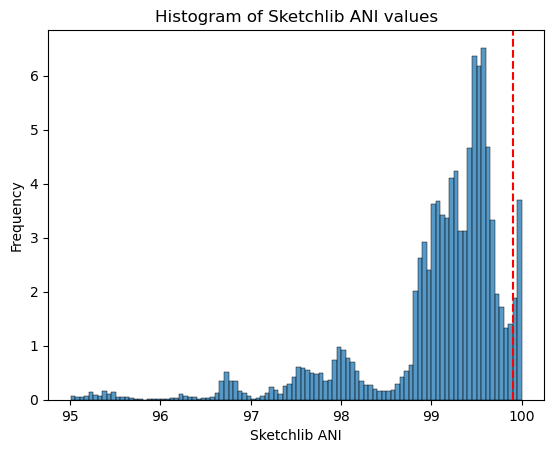

In [45]:
### Create a histogram of sketchlib ANI values to observe frequency
sns.histplot(sketchlib_dist.filter(pl.col('ani') >= 95)['ani'], bins=100, stat='percent')
plt.xlabel('Sketchlib ANI')
plt.ylabel('Frequency')
plt.title('Histogram of Sketchlib ANI values')
# draw vertical line at 95% ANI
plt.axvline(99.9, color='red', linestyle='--')
plt.show()

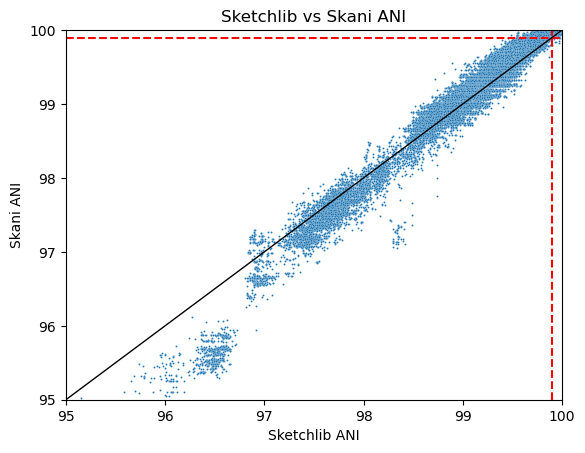

In [20]:
# create scatter plot of sketchlib vs skani ANI values
sns.scatterplot(data=joined, x='ani', y='ani_skani', s=2)
plt.xlabel('Sketchlib ANI')
plt.ylabel('Skani ANI')
plt.title('Sketchlib vs Skani ANI')
plt.xlim(95, 100)
plt.ylim(95, 100)
# draw horizontal line at 95% ANI
plt.axhline(99.9, color='red', linestyle='--')
plt.axvline(99.9, color='red', linestyle='--')
# draw a line that is x=y
plt.plot([95, 100], [95, 100], color='black', linestyle='-', linewidth=1)
plt.show()

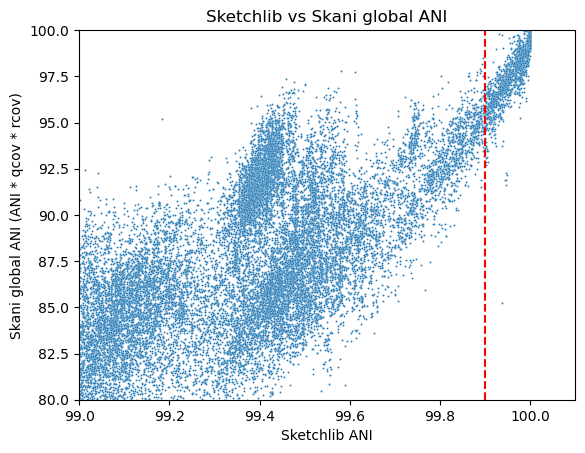

In [21]:
# create scatter plot of sketchlib vs skani ANI values
sns.scatterplot(data=joined, x='ani', y='global_ani', s=2)
plt.xlabel('Sketchlib ANI')
plt.ylabel('Skani global ANI (ANI * qcov * rcov)')
plt.title('Sketchlib vs Skani global ANI')
plt.xlim(99, 100.1)
plt.ylim(80, 100)
# draw horizontal line at 95% ANI
plt.axvline(99.9, color='red', linestyle='--')
plt.show()